In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
df1=pd.read_csv("../data/raw/borrower_profiles.csv")
df2=pd.read_csv("../data/raw/loan_applications.csv")

In [3]:
df1.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


In [4]:
df2.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


## 1. What is the total default rate?

In [5]:
# total_default=df2[df2["defaulted"==1]].count()/df2["loan_id"].count()
number_of_default=df2[df2["defaulted"]==1].count()[0]
total_application=df2["defaulted"].count()
total_default_pct=(number_of_default/total_application)*100
total_default_pct
print("Total Percentage Default:",total_default_pct)

Total Percentage Default: 24.292845257903494


C:\Users\ancha\AppData\Local\Temp\ipykernel_14140\785529587.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  number_of_default=df2[df2["defaulted"]==1].count()[0]


## 2. How does it break down by credit score range? Which credit score bucket has the highest default rate?

In [6]:
df=pd.merge(df1,df2,on="borrower_id")

df["credit_score_bucket"]=pd.cut(
    df["credit_score"],
    bins=[520, 600, 650, 700, 750, 900],
    labels=["520-599","600-649","650-699","700-749","750+"],
    right=False,
)

default_rate=df.groupby("credit_score_bucket")["defaulted"].mean()*100
default_rate

C:\Users\ancha\AppData\Local\Temp\ipykernel_14140\2807185128.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate=df.groupby("credit_score_bucket")["defaulted"].mean()*100


credit_score_bucket
520-599    49.137931
600-649    29.032258
650-699    28.000000
700-749    16.279070
750+       11.688312
Name: defaulted, dtype: float64

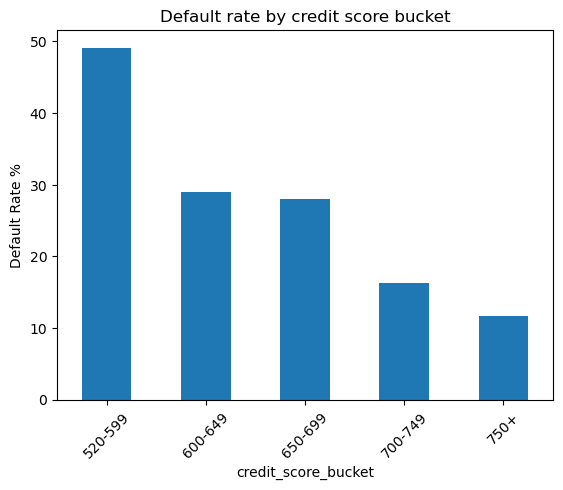

In [7]:
default_rate.plot(kind="bar")
plt.ylabel("Default Rate %")
plt.title("Default rate by credit score bucket")
plt.xticks(rotation=45)

#this clearly shows that highest default rate is for the group of people having credit_score between 520-599.
#it means lesser the credit score, more will be the default risk

plt.savefig(
    r"C:\Users\ancha\Downloads\Loan Default Risk Analysis\Reports\default_rate_by_credit_score.png",
    dpi=300,
    bbox_inches="tight"
)

## 3.Is there a relationship between a borrower’s debt-to-income (DTI) ratio and the likelihood of defaulting?

In [8]:
df["dti_ratio_bucket"]=pd.cut(
    df["dti_ratio"],
    bins=[0,20,40,60,80,90,100,120,180],
    labels=["0-20","21-30%","31-50","51-70","71-90","91-110","110-120","120-180"],
)



dti_based_default_ratio=df.groupby("dti_ratio_bucket")["defaulted"].mean() * 100
dti_based_default_ratio

C:\Users\ancha\AppData\Local\Temp\ipykernel_14140\1965593743.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_based_default_ratio=df.groupby("dti_ratio_bucket")["defaulted"].mean() * 100


dti_ratio_bucket
0-20       16.666667
21-30%     12.169312
31-50      27.979275
51-70      35.294118
71-90      33.333333
91-110     41.666667
110-120    41.666667
120-180    30.000000
Name: defaulted, dtype: float64

In [9]:
df["dti_ratio_bucket"].value_counts()

dti_ratio_bucket
31-50      193
21-30%     189
51-70      119
0-20        48
71-90       18
91-110      12
110-120     12
120-180     10
Name: count, dtype: int64

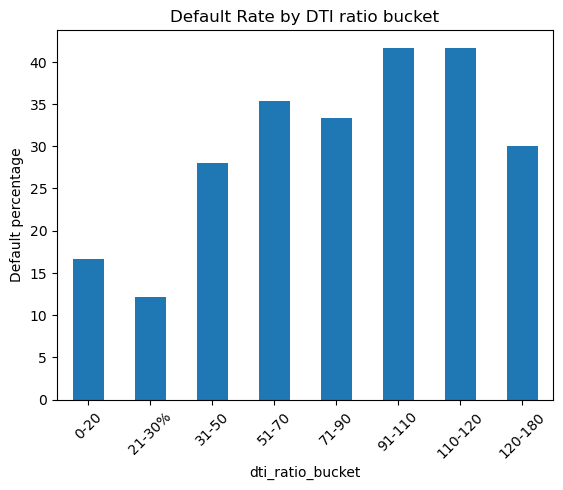

In [10]:
dti_based_default_ratio.plot(kind="bar")
plt.ylabel("Default percentage")
plt.xticks(rotation=45)
plt.title("Default Rate by DTI ratio bucket")
plt.savefig(
    r"C:\Users\ancha\Downloads\Loan Default Risk Analysis\Reports\dti_vs_default_rate.png",
    bbox_inches="tight"
)
# this clearly shows that higher the dti_ratio, higher will be the risk.


##  4. What DTI threshold would you recommend as a cutoff for loan approval?

In [11]:
#BASED ON THE BAR CHART WE HAVE TO CHOOSE THE DTI_RATIO CUTOFF FOR LOAN APPROVAL AND ACCORDING TO THE CHART, THE MOSST SUITABLLE CUTOFF SHOULd BE 21-30% 
#DTI_RATIO.More than that would be more riskier and have a higher chances opf default.

## 5. Which loan purposes have the highest default rates?

In [12]:
loan_purpose_based_default=df.groupby("loan_purpose")["defaulted"].mean() * 100
loan_purpose_based_default

loan_purpose
Auto Loan             27.118644
Business Loan         24.137931
Debt Consolidation    21.568627
Education             22.641509
Home Improvement      28.571429
Major Purchase        22.058824
Medical Expenses      20.588235
Moving                21.428571
Vacation              22.580645
Wedding               32.142857
Name: defaulted, dtype: float64

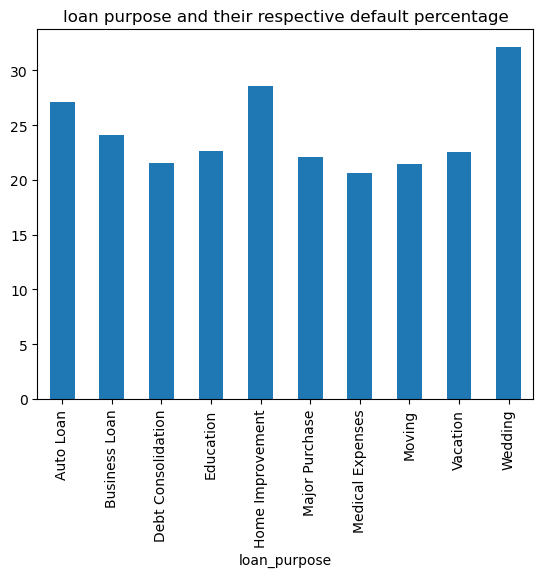

In [13]:
loan_purpose_based_default.plot(kind="bar")
plt.title("loan purpose and their respective default percentage")

plt.savefig(
    r"C:\Users\ancha\Downloads\Loan Default Risk Analysis\Reports\loan_purpose vs_default_rate.png",
    bbox_inches="tight"
)

# wedding has higher default rate

## 6. Does the average loan amount differ significantly between defaulted and non-defaulted loans?

In [14]:
default=df[df["defaulted"]==1]
non_default=df[df["defaulted"]==0]

In [15]:
default_avg=default["loan_amount"].mean()
non_default_avg=non_default["loan_amount"].mean()
avg_diff=default_avg-non_default_avg
print("Average loan amount difference between defaulted and non defaulted loans is:",avg_diff)

Average loan amount difference between defaulted and non defaulted loans is: 557.800692458226


## 7. How do employment status and years employed affect default risk?

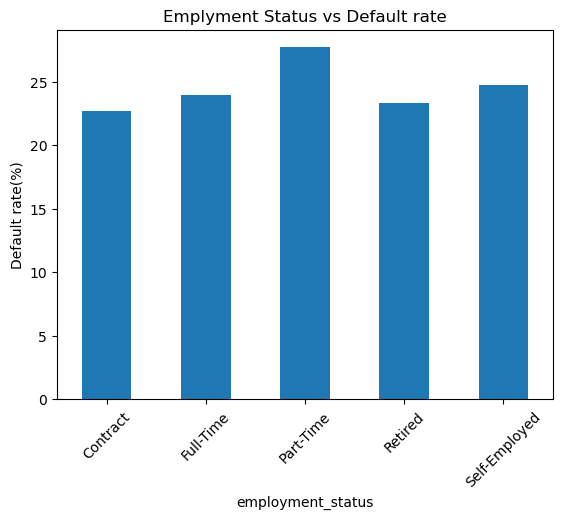

In [16]:
defaultBasedOnEmploymentStatus=df.groupby("employment_status")["defaulted"].mean()*100
defaultBasedOnEmploymentStatus.plot(kind="bar")
plt.title("Emplyment Status vs Default rate")
plt.xticks(rotation=45)
plt.ylabel("Default rate(%)")

plt.savefig(
    r"C:\Users\ancha\Downloads\Loan Default Risk Analysis\Reports\employment_status vs_default_rate.png",
    bbox_inches="tight"
)

C:\Users\ancha\AppData\Local\Temp\ipykernel_14140\2401902993.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  years_employment_based_defaultratio=df.groupby("years_employed_bucket")["defaulted"].mean() * 100


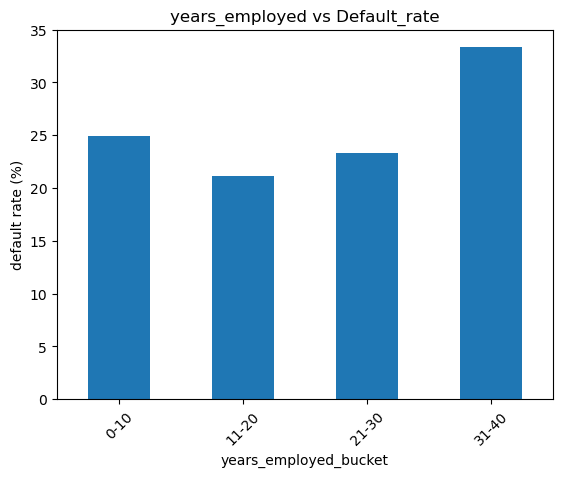

In [17]:
df["years_employed_bucket"]=pd.cut(
    df["years_employed"],
    bins=[0,10,20,30,40],
    labels=["0-10","11-20","21-30","31-40"]
)

years_employment_based_defaultratio=df.groupby("years_employed_bucket")["defaulted"].mean() * 100
years_employment_based_defaultratio.plot(kind="bar")
plt.xticks(rotation=45)
plt.title("years_employed vs Default_rate")
plt.ylabel("default rate (%)")

plt.savefig(
    r"C:\Users\ancha\Downloads\Loan Default Risk Analysis\Reports\years_employed vs_default_rate.png",
    bbox_inches="tight"
)

## Scatterplot of DTI vs Defaulted

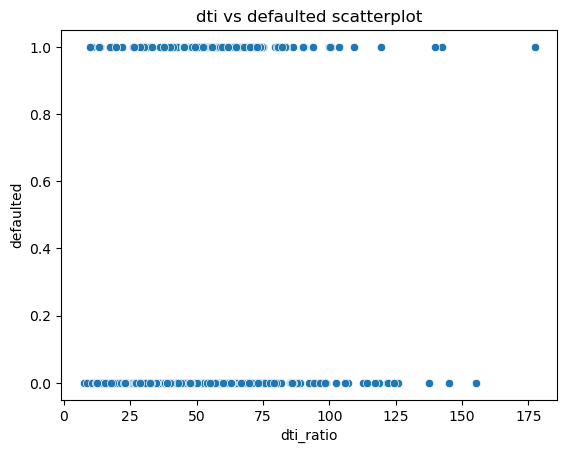

In [18]:
sns.scatterplot(x=df["dti_ratio"],y=df["defaulted"])
plt.title("dti vs defaulted scatterplot")
plt.savefig(
    r"C:\Users\ancha\Downloads\Loan Default Risk Analysis\Reports\dti vs_defaulted scatterplot.png",
    bbox_inches="tight"
)

## 8. Identify which numeric variables (credit score, DTI, income, loan amount, interest rate) have the strongest correlation with defaults.

In [19]:
corr=df[["credit_score","dti_ratio","annual_income","loan_amount","interest_rate","defaulted"]].corr()
corr

,credit_score,dti_ratio,annual_income,loan_amount,interest_rate,defaulted
credit_score,1.000000,-0.121115,0.109968,-0.003482,-0.755153,-0.286394
dti_ratio,-0.121115,1.000000,-0.206438,0.398808,0.103792,0.192454
annual_income,0.109968,-0.206438,1.000000,0.272778,-0.094122,-0.081546
loan_amount,-0.003482,0.398808,0.272778,1.000000,-0.002563,0.018116
interest_rate,-0.755153,0.103792,-0.094122,-0.002563,1.000000,0.198930
defaulted,-0.286394,0.192454,-0.081546,0.018116,0.198930,1.000000


In [20]:
corr["defaulted"].sort_values()

credit_score    -0.286394
annual_income   -0.081546
loan_amount      0.018116
dti_ratio        0.192454
interest_rate    0.198930
defaulted        1.000000
Name: defaulted, dtype: float64

## Heatmap visualisation of correlation

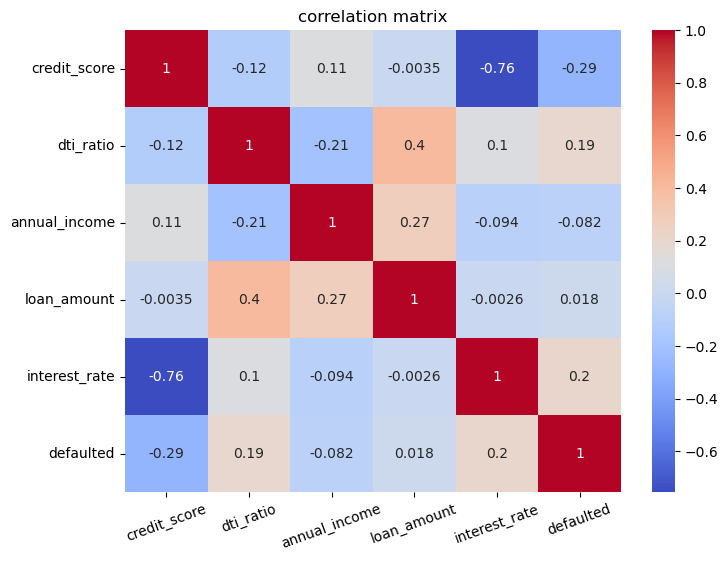

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("correlation matrix")
plt.xticks(rotation=20)


plt.savefig(
    r"C:\Users\ancha\Downloads\Loan Default Risk Analysis\Reports\correlation_matrix.png",
    bbox_inches="tight"
)

## 9. What is the default rate based on the education?


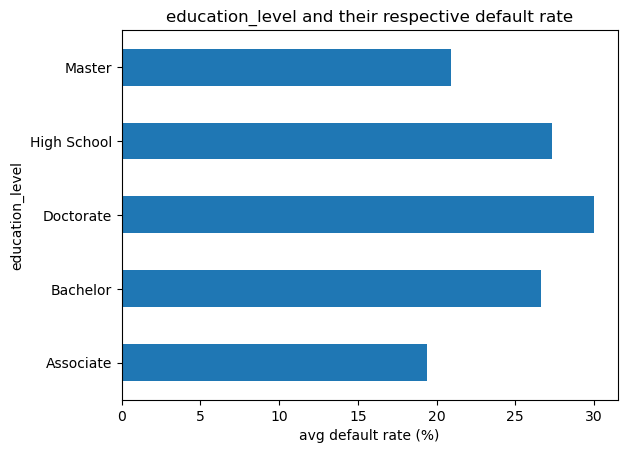

In [22]:
education_default_rate=df.groupby("education_level")["defaulted"].mean() * 100
education_default_rate.plot(kind="barh")
plt.title("education_level and their respective default rate")
plt.xlabel("avg default rate (%)")
plt.savefig(
    r"C:\Users\ancha\Downloads\Loan Default Risk Analysis\Reports\eduaction_level vs default rate.png",
    bbox_inches="tight"
)

## 10. Does age have some effect on default percentage?

In [23]:
print("minimmum age:",df["age"].min())
print("maximum age:",df["age"].max())

minimmum age: 22
maximum age: 68


C:\Users\ancha\AppData\Local\Temp\ipykernel_14140\1984487056.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_based_on_age=df.groupby("age_bucket")["defaulted"].mean() * 100


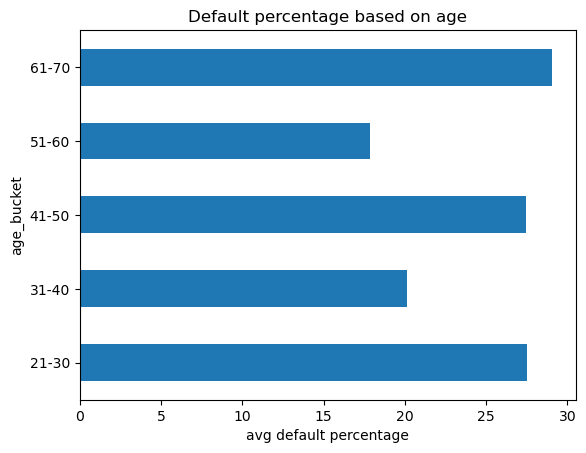

In [24]:
df["age_bucket"]=pd.cut(
    df["age"],
    bins=[20,30,40,50,60,70],
    labels=["21-30","31-40","41-50","51-60","61-70"]
)
default_based_on_age=df.groupby("age_bucket")["defaulted"].mean() * 100
default_based_on_age.plot(kind="barh")
plt.title("Default percentage based on age")
plt.xlabel("avg default percentage")

plt.savefig(
    r"C:\Users\ancha\Downloads\Loan Default Risk Analysis\Reports\age vs default rate.png",
    bbox_inches="tight"
)

In [25]:
print(df["interest_rate"].min())
print(df["interest_rate"].max())


5.86
15.86


## 11. What is the default ratio based on interest rate?

C:\Users\ancha\AppData\Local\Temp\ipykernel_14140\2280788504.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_based_on_interest_rate=df.groupby("interest_rate_bucket")["defaulted"].mean() * 100


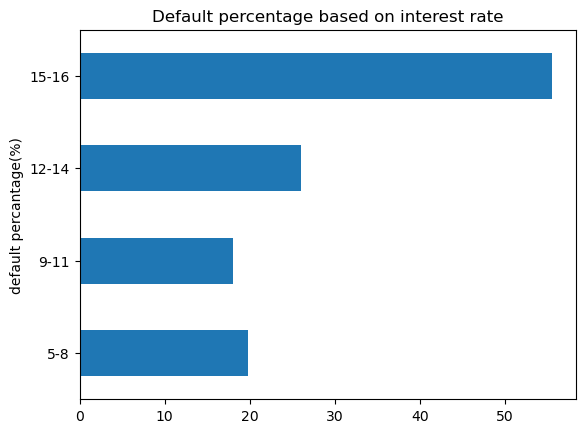

In [30]:
df["interest_rate_bucket"]=pd.cut(
    df["interest_rate"],
    bins=[5,8,11,14,17],
    labels=["5-8","9-11","12-14","15-16"]
)
default_based_on_interest_rate=df.groupby("interest_rate_bucket")["defaulted"].mean() * 100
default_based_on_interest_rate.plot(kind="barh")
plt.ylabel("default percantage(%)")
plt.title("Default percentage based on interest rate") 

plt.savefig(
    r"C:\Users\ancha\Downloads\Loan Default Risk Analysis\Reports\interest_rate vs default rate.png",
    bbox_inches="tight"
)

# higher the interest rate,high chances of default will be

## 12. Top 10  state with high Default rate?

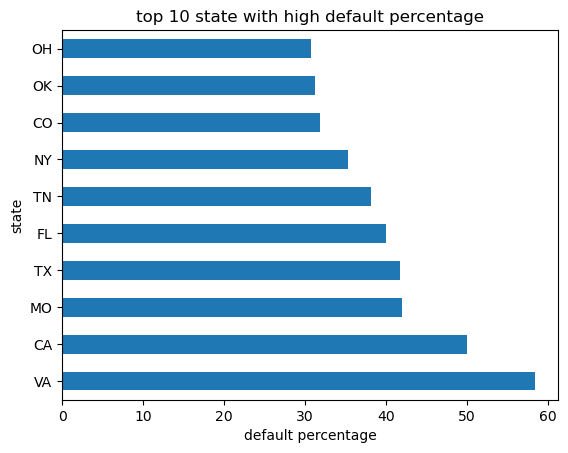

In [54]:
state_default=df.groupby("state")["defaulted"]. mean() * 100
top_10=state_default.sort_values(ascending=False).head(10)
top_10.plot(kind="barh")
plt.title("top 10 state with high default percentage")
plt.xlabel("default percentage")

plt.savefig(
    r"C:\Users\ancha\Downloads\Loan Default Risk Analysis\Reports\state vs default rate.png",
    bbox_inches="tight"
)